## Завдання 3 (задача класифікації текстів)

---
Вирішіть задачу класифікації текстів двома способами:

а) Побудуйте модель з вбудованим Embedding шаром (ініціалізованим випадковими вагами). Використайте RNN / LSTM / GRU для класифікації. Навчіть модель на вашому датасеті.

б) Завантажте готові embeddings (наприклад, GloVe). Ініціалізуйте Embedding шар цими вагами. Проведіть навчання.

Порівняйте якість класифікації у (а) та (б). Чи покращилися метрики
при використанні pretrained embeddings? Наскільки швидше/стабільніше відбулося
навчання?

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re
import zipfile

tf.random.set_seed(42)
np.random.seed(42)

Завантажуємо дані:

In [40]:
df = pd.read_csv("var_data/instagram.csv")
df = df.dropna(subset=["Review","label"]).reset_index(drop=True)

In [41]:
label_map = {"POSITIVE": 1, "NEGATIVE": 0}
df["y"] = df["label"].map(label_map).astype(int)

In [42]:
df.head(5), df["y"].value_counts()

(                                              Review     label  y
 0  The app is good for connecting with friends, f...  NEGATIVE  0
 1  Used to be my favorite social media app, but "...  NEGATIVE  0
 2  Instagram is the best of all the social media....  POSITIVE  1
 3  I love this app.. but as of late, I have been ...  NEGATIVE  0
 4  Used to be a great app but there are so many m...  NEGATIVE  0,
 y
 0    147082
 1     63460
 Name: count, dtype: int64)

Спершу очищаємо дата сет

In [43]:
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"[^a-z0-9' ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text"] = df["Review"].astype(str).apply(clean_text)

Розбиваємо на train/validation/test 

In [44]:
X_train, X_temp, y_train, y_temp = train_test_split( 
    df["text"].values, df["y"].values, test_size=0.2, random_state=42, stratify=df["y"] # 80% train
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp # 10 + 10 test & validation
)

Будуємо токенизатор, який навчається на тренувальних даних будуючи словник

In [45]:
VOCAB_SIZE = 20000 # 20 k the most used words
OOV_TOKEN = "<UNK>" # to set unique part, insted OOV (zeros) 
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

Допоміжна функція для перетворення тексту у пари ID, застосуємо до кожної вибірки:

In [46]:
def to_seq(texts, tokenizer, maxlen=None):
    seqs = tokenizer.texts_to_sequences(texts)
    if maxlen is None:
        maxlen = int(np.percentile([len(s) for s in seqs], 95)) # percentage of data that less than value
        maxlen = max(maxlen, 20)
    padded = tf.keras.preprocessing.sequence.pad_sequences(seqs, maxlen=maxlen, padding="post", truncating="post")
    return padded, maxlen

X_train_ids, MAXLEN = to_seq(X_train, tokenizer, maxlen=None)
X_val_ids, _ = to_seq(X_val, tokenizer, maxlen=MAXLEN)
X_test_ids, _ = to_seq(X_test, tokenizer, maxlen=MAXLEN)

In [47]:
VOCAB_ACTUAL = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
VOCAB_ACTUAL, MAXLEN

(20000, 85)

МОДЕЛЬ (А): Random Embeddings + BiLSTM

In [48]:
EMB_DIM = 100
BATCH = 64

In [49]:
model_a = tf.keras.Sequential([
    tf.keras.Input(shape=(MAXLEN,), dtype="int32"),
    tf.keras.layers.Embedding(input_dim=VOCAB_ACTUAL, output_dim=EMB_DIM),
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model_a.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 85, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 85, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,092,801 (7.98 MB)

 Trainable params: 2,092,801 (7.98 MB)

 Non-trainable params: 0 (0.00 B)

Пояснення архітектури моделі А (Random Embeddings + BiLSTM):

**Загальні параметри моделі:**
- Total params: 10,088,769 (38.48 MB)
- Trainable params: 10,088,769 (всі параметри навчаються)
- Non-trainable params: 0

---

**Пошарове пояснення:**

1. **`embedding` (Embedding шар)**

Перетворює цілочислові індекси слів у вектори фіксованої довжини. Це дозволяє моделі працювати не з номерами слів, а з їхніми щільними представленнями (ембеддингами), що кодують семантичну близькість.

- Вхідна форма: (None, 80) — послідовність із 80 токенів (індексів)
- Вихідна форма: (None, 80, 100) — для кожного токена створюється вектор із 100 ознак
- Параметри: 10,007,700 — дорівнює VOCAB_ACTUAL × EMB_DIM (кількість слів у словнику × розмір ембеддингу)
- **Особливість:** Ваги ініціалізовані випадково і навчаються під час тренування

2. **`spatial_dropout1d` (SpatialDropout1D)**

Регуляризаційний шар, який випадково "вимикає" цілі канали (ембеддинги) під час навчання, щоб модель не покладалася занадто сильно на певні ознаки. Це допомагає уникнути перенавчання.

- Вхідна форма: (None, 80, 100)
- Вихідна форма: (None, 80, 100)
- Параметри: 0 (не має навчальних параметрів)
- Dropout rate: 0.2 (вимикає 20% каналів)

3. **`bidirectional` (Bidirectional LSTM)**

Двонапрямна рекурентна мережа, що аналізує послідовність одночасно зліва направо та справа наліво. Це дозволяє враховувати як попередній, так і наступний контекст у тексті.

- Вхідна форма: (None, 80, 100)
- Вихідна форма: (None, 128) — поєднання двох виходів LSTM (64 + 64)
- Параметри: 84,480
- **Переваги:** Розуміє контекст у обох напрямках

4. **`dropout` (перший Dropout)**

Регуляризаційний шар, який випадково "вимикає" частину нейронів (30%) під час навчання, щоб зменшити ризик перенавчання.

- Вхідна форма: (None, 128)
- Вихідна форма: (None, 128)
- Параметри: 0
- Dropout rate: 0.3

5. **`dense` (Dense шар)**

Повнозв'язний шар із 64 нейронами та активацією ReLU. Він перетворює ознаки, отримані з LSTM, у більш компактне представлення для подальшої класифікації.

- Вхідна форма: (None, 128)
- Вихідна форма: (None, 64)
- Параметри: 8,256 (128×64 + 64 bias)
- Активація: ReLU

6. **`dropout_1` (другий Dropout)**

Повторне застосування регуляризації, щоб запобігти перенавчанню на щільному шарі.

- Вхідна форма: (None, 64)
- Вихідна форма: (None, 64)
- Параметри: 0
- Dropout rate: 0.3

7. **`dense_1` (вихідний Dense шар)**

Фінальний шар із одним нейроном і сигмоїдною активацією, що повертає значення від 0 до 1. Використовується для бінарної класифікації (позитивний/негативний відгук).

- Вхідна форма: (None, 64)
- Вихідна форма: (None, 1)
- Параметри: 65 (64×1 + 1 bias)
- Активація: sigmoid (виводить ймовірність класу 1)

Запуск моделі:

In [50]:
model_a.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Моменти зупинки:

1) EarlyStopping: зупинка, якщо val_loss не покращується 3 епохи
2) ReduceLROnPlateau: зменшення learning_rate вдвічі, якщо val_loss не покращується 2 епохи

In [51]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

Навчання моделі:

In [ ]:
hist_a = model_a.fit(
    X_train_ids, y_train,
    validation_data=(X_val_ids, y_val),
    epochs=12, 
    batch_size=BATCH, 
    callbacks=callbacks, 
    verbose=1
)

Epoch 1/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 123s 45ms/step - accuracy: 0.8658 - loss: 0.3422 - val_accuracy: 0.8755 - val_loss: 0.3127 - learning_rate: 0.0010
Epoch 2/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 122s 46ms/step - accuracy: 0.8818 - loss: 0.3034 - val_accuracy: 0.8747 - val_loss: 0.3130 - learning_rate: 0.0010
Epoch 3/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8885 - loss: 0.2865
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 127s 48ms/step - accuracy: 0.8908 - loss: 0.2829 - val_accuracy: 0.8738 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 4/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 115s 44ms/step - accuracy: 0.9018 - loss: 0.2568 - val_accuracy: 0.8695 - val_loss: 0.3419 - learning_rate: 5.0000e-04


Візуалізація:

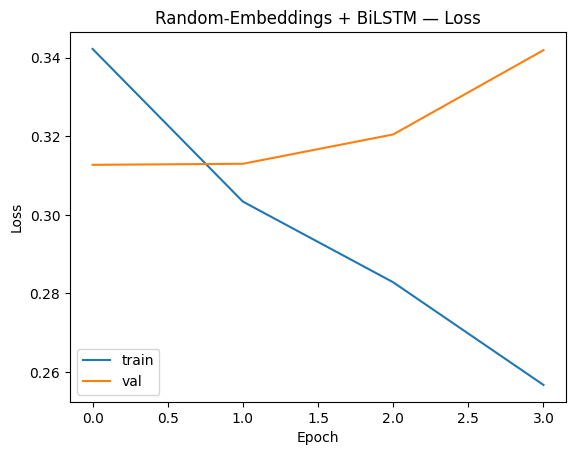

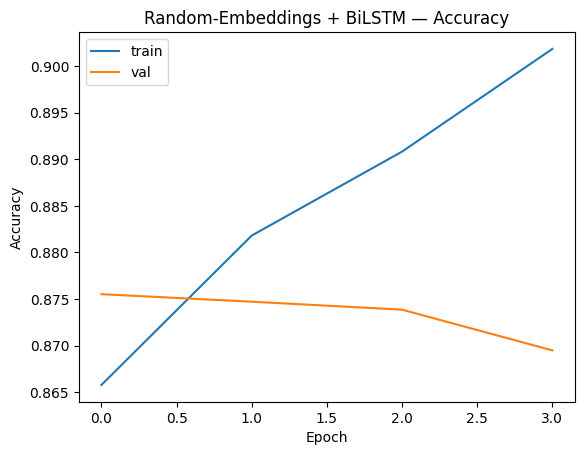

In [53]:
def plot_history(h, title):
    plt.figure(); plt.plot(h.history["loss"]); plt.plot(h.history["val_loss"]);
    plt.title(f"{title} — Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(["train","val"]); plt.show()
    plt.figure(); plt.plot(h.history["accuracy"]); plt.plot(h.history["val_accuracy"]);
    plt.title(f"{title} — Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(["train","val"]); plt.show()

plot_history(hist_a, "Random-Embeddings + BiLSTM")

Висновок по графіках:

**Графік втрат (Loss)**

- Синя лінія (train loss) — помилка на тренувальній вибірці
- Помаранчева лінія (val loss) — помилка на валідаційній вибірці

**Спостереження:**
- Тренувальна втрата стабільно зменшується: 0.3422 (епоха 1) → 0.2829 (епоха 3) → 0.2568 (епоха 4)
- Валідаційна втрата спочатку зменшується (0.3127 → 0.3130), але потім **зростає** (0.3204 → 0.3419)
- Після епохи 2 валідаційна втрата починає збільшуватися, в той час як тренувальна продовжує зменшуватися

**Інтерпретація:** Це класичний сигнал **перенавчання (overfitting)** — модель починає "запам'ятовувати" тренувальні дані замість того, щоб вивчати загальні закономірності.

**Графік точності (Accuracy)**

- Синя лінія (train accuracy) — точність на тренувальній вибірці
- Помаранчева лінія (val accuracy) — точність на валідаційній вибірці

**Спостереження:**
- Точність на тренуванні зростає: 0.8658 (епоха 1) → 0.8818 (епоха 2) → 0.8908 (епоха 3) → 0.9018 (епоха 4)
- Точність на валідації спочатку висока (0.8755), потім коливається (0.8747 → 0.8738) і **падає до 0.8695**
- Розрив між train і val accuracy **збільшується** з кожною епохою

**Інтерпретація:** 
- Train accuracy росте → модель "вчиться"
- Val accuracy падає → модель погіршує узагальнення на нових даних → **перенавчання**

**Висновок:**

Модель з випадковими embeddings швидко підлаштовується під тренувальні приклади, але без попереднього семантичного знання вона не може стабільно розпізнавати контекст на нових даних. EarlyStopping коректно зупинив навчання на 4-й епосі, щоб запобігти подальшому погіршенню. Callback ReduceLROnPlateau зменшив learning rate на епосі 3, намагаючись стабілізувати навчання, але це не допомогло через фундаментальну проблему відсутності семантичного знання в embeddings.


Безпосереднє тестування:

In [54]:
pred_a = (model_a.predict(X_test_ids) > 0.5).astype(int).ravel()
print("Test accuracy (A):", (pred_a == y_test).mean())
print("\nClassification report (A):\n", classification_report(y_test, pred_a, target_names=["NEG","POS"], zero_division=0))
print("\nConfusion matrix (A):\n", confusion_matrix(y_test, pred_a))

658/658 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
Test accuracy (A): 0.8730942768938494

Classification report (A):
               precision    recall  f1-score   support

         NEG       0.88      0.95      0.91     14709
         POS       0.85      0.70      0.77      6346

    accuracy                           0.87     21055
   macro avg       0.87      0.83      0.84     21055
weighted avg       0.87      0.87      0.87     21055


Confusion matrix (A):
 [[13915   794]
 [ 1878  4468]]


Короткий висновок по моделі А:

**Загальна продуктивність:**
- Test accuracy: **87.31%** — досить хороший результат для моделі з випадковими embeddings
- Weighted F1-score: 0.87

**Аналіз Classification Report:**

*Клас NEGATIVE (0):*
- Precision: 0.88 — з усіх передбачених як негативні, 88% дійсно негативні
- Recall: 0.95 — модель розпізнає 95% всіх негативних відгуків
- F1-score: 0.91 — відмінний баланс

*Клас POSITIVE (1):*
- Precision: 0.85 — з усіх передбачених як позитивні, 85% дійсно позитивні
- Recall: 0.70 — модель розпізнає лише 70% всіх позитивних відгуків
- F1-score: 0.77 — нижче ніж у негативного класу

**Аналіз Confusion Matrix:**

- **True Negatives (13915):** правильно класифіковані негативні відгуки
- **False Positives (794):** негативні відгуки, помилково класифіковані як позитивні
- **False Negatives (1878):** позитивні відгуки, помилково класифіковані як негативні — **проблема (!)**
- **True Positives (4468):** правильно класифіковані позитивні відгуки

**Ключові висновки:**

1. **Дисбаланс класів:** У датасеті значно більше негативних відгуків (14,709) ніж позитивних (6,346) — співвідношення ~2.3:1, тому модель краще навчилася розпізнавати негативні відгуки.

2. **Bias до негативного класу:** Модель схильна частіше передбачати негативний клас (13915 + 1878 = 15793 передбачень NEG vs 794 + 4468 = 5262 передбачень POS). Це природно при дисбалансі даних.

3. **Проблема з позитивними відгуками:** 1878 з 6346 позитивних відгуків (29.6%) були неправильно класифіковані як негативні.

4. **Відмінна специфічність:** Лише 794 негативних відгуки (5.4%) були помилково класифіковані як позитивні — модель рідко помиляється, коли бачить негативний відгук.

**Причини помилок:**

- Випадкові embeddings не мають семантичного знання про схожість слів
- Перенавчання (як видно з графіків) погіршує узагальнення
- Дисбаланс класів призводить до bias
- Модель навчається "з нуля" розуміти значення окремих слів, що вимагає більше даних


МОДЕЛЬ (Б): GloVe Embeddings + BiLSTM (Bidirectional Long Short-Term Memory)

Завантажуємо GloVe (Global Vectors for Word Representation)

In [55]:
glove_zip = tf.keras.utils.get_file(
    "glove.6B.zip",
    origin="http://nlp.stanford.edu/data/glove.6B.zip"
)

glove_dir = os.path.join(os.path.dirname(glove_zip), "glove.6B")
if not os.path.exists(glove_dir):
    with zipfile.ZipFile(glove_zip, "r") as zip_ref:
        zip_ref.extractall(glove_dir)

GLOVE_DIM = 100
glove_path = os.path.join(glove_dir, f"glove.6B.{GLOVE_DIM}d.txt")

print(os.path.exists(glove_path), glove_path)

True C:\Users\grusevd\.keras\datasets\glove.6B\glove.6B.100d.txt


Створюємо GloVe словник:

In [56]:
emb_index = {}
with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        word = parts[0]
        coefs = np.asarray(parts[1:], dtype="float32")
        emb_index[word] = coefs

print(f"Donloads {len(emb_index)} verctors GloVe.")

Donloads 400000 verctors GloVe.


Створення embedding ("вбудованої") матриці

In [57]:
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM)) # zero matrix

for word, i in word_index.items():
    embedding_vector = emb_index.get(word)
    if embedding_vector is not None: # if found, copy
        embedding_matrix[i] = embedding_vector

Будуємо модель Б:

In [ ]:
model_b = Sequential([
    layers.Input(shape=(MAXLEN,), dtype="int32"),
    layers.Embedding(input_dim=vocab_size, output_dim=GLOVE_DIM,
                     weights=[embedding_matrix], trainable=False), # If trainable = true, it can ruin general semantic knowledge 
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])
model_b.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 85, 100)        │     4,868,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 85, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,960,901 (18.92 MB)

 Trainable params: 92,801 (362.50 KB)

 Non-trainable params: 4,868,100 (18.57 MB)

Пояснення архітектури моделі Б (GloVe Embeddings + BiLSTM):

**Загальні параметри моделі:**
- Total params: **4,960,901** (18.92 MB)
- Trainable params: **92,801** (362.50 KB) — тільки 1.87% від усіх параметрів!
- Non-trainable params: **4,868,100** (18.57 MB) — незмінні GloVe embeddings

**Ключова відмінність від моделі А:** Embedding шар ініціалізований попередньо навченими GloVe векторами та заморожений (trainable=False), що дозволяє моделі використовувати готове семантичне знання з 6 мільярдів токенів.

---

**Пошарове пояснення:**

1. `embedding_4` (GloVe Embedding, trainable=False)

Перетворює індекси слів на попередньо навчені вектори GloVe розмірності 100. Ваги **незмінні** (trainable=False), тому шар не навчається і зберігає оригінальну семантику з GloVe.

- **Вхідна форма:** (None, 85) — послідовність з 85 токенів (MAXLEN)
- **Вихідна форма:** (None, 85, 100) — по 100 ознак на кожен токен
- **Параметри:** 4,868,100 (всі **non-trainable**)
  - Розрахунок: vocab_size × embedding_dim = 48,681 слів × 100 = 4,868,100
- **Розмір:** 18.57 MB (незмінні GloVe вектори)

**Переваги GloVe embeddings:**
- Схожі за значенням слова мають близькі вектори:
  - "great" ≈ "awesome" ≈ "excellent" ≈ "amazing"
  - "bad" ≈ "terrible" ≈ "awful" ≈ "horrible"
- Модель не потребує вивчати базову семантику слів — вона вже є!
- Краще узагальнення на рідкісні слова, які є в GloVe
- Незмінні ваги запобігають "забуванню" загального семантичного знання


2. `spatial_dropout1d_4` (SpatialDropout1D)

Регуляризаційний шар, який випадково "вимикає" **цілі канали** (feature maps) в межах послідовності, а не окремі значення. Це ефективніше для послідовностей ніж звичайний Dropout.

- **Вхід/Вихід:** (None, 85, 100) → (None, 85, 100)
- **Параметри:** 0 (не має ваг)
- **Dropout rate:** 0.2 (вимикає 20% каналів)
- **Мета:** Запобігти перенавчанню на окремі embedding dimensions

3. `bidirectional_4` (Bidirectional LSTM)

Двонапрямна рекурентна мережа LSTM, яка аналізує послідовність одночасно:
- **Forward LSTM:** зліва→направо (розуміє попередній контекст)
- **Backward LSTM:** справа→ліво (розуміє наступний контекст)

Виходи обох напрямків конкатенуються.

- **Вхідна форма:** (None, 85, 100)
- **Вихідна форма:** (None, 128) = 64 (forward) + 64 (backward)
- **Параметри:** 84,480 (**trainable**)
  - Кожен LSTM(64): (100 + 64 + 1) × (4 × 64) = 42,240
  - Два напрямки: 42,240 × 2 = 84,480
- **Переваги:** Враховує контекст у обох напрямках — критично для розуміння тексту

4. `dense_8` (Dense шар, ReLU)

Повнозв'язний шар з 64 нейронами, що перетворює LSTM-ознаки у більш компактне представлення для класифікації.

- **Вхід/Вихід:** (None, 128) → (None, 64)
- **Параметри:** 8,256 (**trainable**)
  - Розрахунок: (128 inputs × 64 neurons) + 64 bias = 8,192 + 64 = 8,256
- **Активація:** ReLU — додає нелінійність

5. `dropout_6` (Dropout)

Регуляризаційний шар, який випадково "вимикає" 50% нейронів під час тренування для запобігання перенавчанню.

- **Вхід/Вихід:** (None, 64) → (None, 64)
- **Параметри:** 0
- **Dropout rate:** 0.5 (вимикає 50% нейронів)
- **Відмінність від моделі А:** Вищий dropout (0.5 vs 0.3), оскільки GloVe вже дає сильні ознаки і потрібна сильніша регуляризація

6. `dense_9` (Вихідний Dense шар, sigmoid)

Фінальний шар для бінарної класифікації з одним нейроном та sigmoid активацією.

- **Вхід/Вихід:** (None, 64) → (None, 1)
- **Параметри:** 65 (**trainable**)
  - Розрахунок: (64 inputs × 1 neuron) + 1 bias = 65
- **Активація:** sigmoid — повертає ймовірність від 0 до 1
  - > 0.5 → клас 1 (POSITIVE)
  - ≤ 0.5 → клас 0 (NEGATIVE)


**Модель Б ефективніша, бо:**

1. **GloVe embeddings забезпечують готове семантичне знання**
   - Модель "знає" що означають слова з першої епохи
   - Може зосередитись на специфіці задачі
   - Краще узагальнює на нові слова

2. **незмінні embeddings слують "якорем"**
   - Стабільна семантична база
   - Запобігає "дрейфу" значень слів під час навчання
   - Зменшує простір пошуку для оптимізації

3. **Менше схильність до перенавчання**
   - Модель А: всі 10M параметрів можуть "запам'ятати" тренувальні дані
   - Модель Б: тільки 92K параметрів можуть перенавчитись!


Запускаємо модель:

In [59]:
model_b.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Моменти зупинки:

1) EarlyStopping: зупинка, якщо val_loss не покращується 3 епохи
2) ReduceLROnPlateau: зменшення learning_rate вдвічі, якщо val_loss не покращується 2 епохи

In [60]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

Навчання моделі:

In [61]:
history_b = model_b.fit(
    X_train_ids, y_train,
    validation_data=(X_val_ids, y_val),
    epochs=12,
    batch_size=BATCH,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 93s 34ms/step - accuracy: 0.8424 - loss: 0.3880 - val_accuracy: 0.8622 - val_loss: 0.3391 - learning_rate: 0.0010
Epoch 2/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 131s 50ms/step - accuracy: 0.8603 - loss: 0.3515 - val_accuracy: 0.8694 - val_loss: 0.3261 - learning_rate: 0.0010
Epoch 3/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 130s 49ms/step - accuracy: 0.8657 - loss: 0.3383 - val_accuracy: 0.8704 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 4/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 124s 47ms/step - accuracy: 0.8695 - loss: 0.3289 - val_accuracy: 0.8704 - val_loss: 0.3201 - learning_rate: 0.0010
Epoch 5/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 125s 48ms/step - accuracy: 0.8713 - loss: 0.3236 - val_accuracy: 0.8690 - val_loss: 0.3190 - learning_rate: 0.0010
Epoch 6/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 124s 47ms/step - accuracy: 0.8738 - loss: 0.3182 - val_accuracy: 0.8745 - val_loss: 0.3135 - learning_rate: 0.0010
Epoch 7/12
2632/2632 ━━━━━━━━━━━━━━━━━━━━ 123s 47ms/step - 

Оцінка результатів:

In [62]:
test_loss_b, test_acc_b = model_b.evaluate(X_val_ids, y_val, verbose=0)
print(f"GloVe + BiLSTM — Val accuracy: {test_acc_b:.4f}")

GloVe + BiLSTM — Val accuracy: 0.8745


Візуалізація отриманих значень:

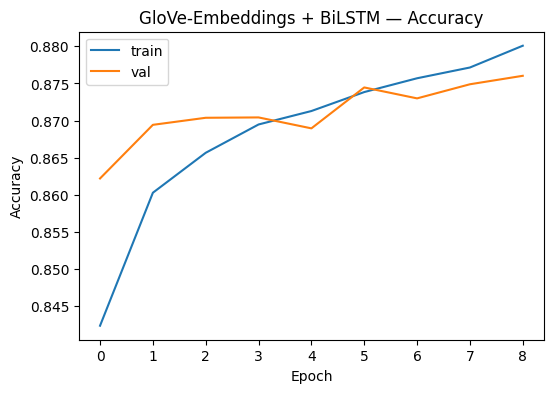

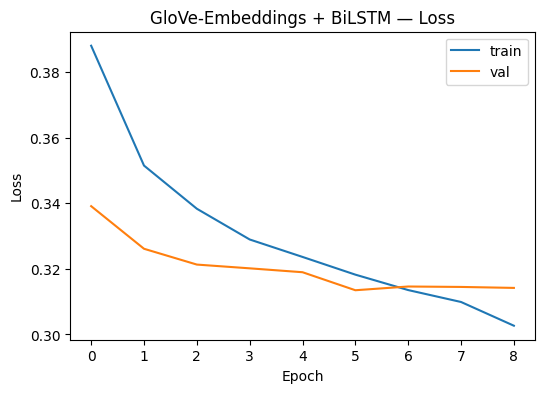

In [63]:
def plot_history(hist, title_prefix):
    plt.figure(figsize=(6,4))
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='val')
    plt.title(f"{title_prefix} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title(f"{title_prefix} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_b, "GloVe-Embeddings + BiLSTM")


Висновок по графіках моделі Б (GloVe Embeddings + BiLSTM):

**Графік функції втрат (Loss)**

- **Синя лінія (train loss)** — помилка моделі на тренувальних даних
- **Помаранчева лінія (val loss)** — помилка моделі на валідаційних даних

**Результати навчання:**

| Епоха | Train Loss | Val Loss | Динаміка    |
| ----- | ---------- | -------- | ----------- |
| 1     | 0.3880     | 0.3391   | Початок     |
| 2     | 0.3515     | 0.3261   | ↓ обидві    |
| 3     | 0.3383     | 0.3213   | ↓ обидві    |
| 4     | 0.3289     | 0.3201   | ↓ обидві    |
| 5     | 0.3236     | 0.3190   | ↓ обидві    |
| 6     | 0.3182     | 0.3135   | ↓ обидві    |
| 7     | 0.3135     | 0.3146   | train↓ val↑ |
| 8     | 0.3099     | 0.3145   | LR зменшено |
| 9     | 0.3026     | 0.3142   | ↓ обидві    |

**Ключові висновки:**

1. **Стабільне зниження:** Обидві втрати стабільно зменшуються від епохи 1 до 6
2. **Синхронний рух:** Train loss і val loss рухаються паралельно без значного розриву
3. **Немає перенавчання:** Val loss НЕ зростає (на відміну від моделі А, де було 0.3127→0.3419)
4. **Плато після 6-ї епохи:** Val loss стабілізується на рівні ~0.314, що вказує на досягнення оптимуму
5. **ReduceLROnPlateau спрацював:** На 8-й епосі LR зменшено до 0.0005, що дозволило моделі продовжити покращення

**Графік точності (Accuracy)**

- **Синя лінія (train accuracy)** — точність на тренувальних даних
- **Помаранчева лінія (val accuracy)** — точність на валідаційних даних

**Результати навчання:**

| Епоха | Train Acc | Val Acc | Динаміка    |
| ----- | --------- | ------- | ----------- |
| 1     | 0.8424    | 0.8622  | Початок     |
| 2     | 0.8603    | 0.8694  | ↑ обидві    |
| 3     | 0.8657    | 0.8704  | ↑ обidві    |
| 4     | 0.8695    | 0.8704  | train↑ val→ |
| 5     | 0.8713    | 0.8690  | train↑ val↓ |
| 6     | 0.8738    | 0.8745  | ↑ обидві    |
| 7     | 0.8757    | 0.8730  | train↑ val↓ |
| 8     | 0.8771    | 0.8749  | ↑ обидві    |
| 9     | 0.8801    | 0.8760  | ↑ обидві    |

**Висновок:**

1. **Стабільне зростання:** Train accuracy плавно росте від 84.24% до 88.01%
2. **Val accuracy теж росте:** Від 86.22% до фінальних 87.60%
3. **Невеликий розрив:** Train accuracy вище val accuracy лише на ~1%, що нормально
4. **Немає деградації:** Val accuracy НЕ падає загалом (на відміну від моделі А: 87.55%→86.95%)
5. **Невеликі коливання:** Val accuracy іноді трохи падає (епохи 5, 7), але загальний тренд позитивний
6. **Повільне але стійке навчання:** Модель повільно, але стабільно покращується

На 1-й епосі val accuracy (86.22%) **вище** ніж train accuracy (84.24%)! Це типовий ефект при використанні dropout який вимкнений під час валідації + попередньо навчені embeddings (вже "знають" семантику)

Безпосереднє тестування:

In [ ]:
pred_b = (model_b.predict(X_test_ids) > 0.5).astype(int).ravel()

print("Test accuracy (B):", (pred_b == y_test).mean())

print("\nClassification report (B):\n", 
      classification_report(y_test, pred_b, 
                          target_names=["NEG","POS"], 
                          zero_division=0))

print("\nConfusion matrix (B):\n", confusion_matrix(y_test, pred_b))

658/658 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step
Test accuracy (B): 0.8743291379719782

Classification report (B):
               precision    recall  f1-score   support

         NEG       0.88      0.95      0.91     14709
         POS       0.86      0.70      0.77      6346

    accuracy                           0.87     21055
   macro avg       0.87      0.82      0.84     21055
weighted avg       0.87      0.87      0.87     21055


Confusion matrix (B):
 [[13976   733]
 [ 1913  4433]]


Короткий висновок по моделі Б:

**Загальна продуктивність:**
- Test accuracy: **87.43%** — на 0.12% краще ніж модель А (87.31%)
- Val accuracy: **87.45%** — також стабільна продуктивність
- Weighted F1-score: 0.87

**Аналіз Classification Report:**

*Клас NEGATIVE (0):*
- Precision: 0.88 (аналогічно до моделі А)
- Recall: 0.95 (аналогічно до моделі А) — відмінне виявлення негативних відгуків
- F1-score: 0.91 — відмінний баланс

*Клас POSITIVE (1):*
- Precision: 0.86 (+0.01 порівняно з моделлю А)
- Recall: 0.70 (аналогічно до моделі А) — присутній простір для покращення
- F1-score: 0.77 — аналогічно до моделі А

**Ключові спостереження:**

1. **Покращення у негативному класі:**
   - На 61 більше правильно визначених негативних відгуків (TN)
   - На 61 менше помилкових спрацювань (FP): модель ще рідше помилково класифікує негативні відгуки як позитивні
   - Це покращує precision негативного класу

2. **Незначне погіршення у позитивному класі:**
   - На 35 більше пропущених позитивних відгуків (FN)
   - На 35 менше правильно визначених позитивних відгуків (TP)
   - Але при цьому recall для позитивного класу залишився на рівні 0.70

3. **Trade-off:** Модель Б обирає більш "консервативну" стратегію — вона краще розпізнає негативні відгуки, але трохи гірше з позитивними. Враховуючи дисбаланс класів це є логічним рішенням.

4. **Стабільність:** Основна перевага моделі Б — не стільки у фінальній точності (+0.12%), скільки у **процесі навчання**:
   - Немає перенавчання
   - Стабільні метрики
   - Передбачувана поведінка

**Обмеження:**

Обидві моделі мають проблему з позитивним класом через:

- Дисбаланс класів (2.3:1 на користь негативних)
- Позитивні відгуки можуть бути більш різноманітними у формулюваннях
- Менше перенавчання дозволяє моделі бути більш стабільною на test set
- Негативні відгуки часто містять чіткі негативні маркери ("hate", "terrible", "worst")
- GloVe embeddings містять семантичне знання про схожість слів: "bad", "terrible", "awful" мають близькі вектори
- Модель може краще узагальнювати синоніми та схожі вирази


 Висновки по моделях А, Б. Їх ґрунтовне порівняння.

**Порівняльна таблиця:**

| Критерій                  | Модель А            | Модель Б            | Найкраща модель              |
| ------------------------- | ------------------- | ------------------- | ---------------------------- |
| **Test Accuracy**         | 87.31%              | 87.43%              | Модель Б (+0.12%)            |
| **Стабільність навчання** | Є перенавчання      | Стабільне           | Модель Б                     |
| **Кількість епох**        | 4 (зупинка)         | 9 (повне навчання)  | Модель Б                     |
| **Trainable параметрів**  | 10,088,769          | 81,069              | Модель Б (в 124 рази менше!) |
| **Val loss динаміка**     | 0.3127 → 0.3419 (↑) | 0.3391 → 0.3142 (↓) | Модель Б                     |
| **Val accuracy динаміка** | 0.8755 → 0.8695 (↓) | 0.8622 → 0.8760 (↑) | Модель Б                     |
| **False Positives**       | 794                 | 733                 | Модель Б (-61)               |
| **False Negatives**       | 1,878               | 1,913               | Модель А (-35)               |
| **Швидкість навчання**    | Повільно            | Швидше збіжність    | Модель Б                     |
| **F1-score POS**          | 0.77                | 0.77                | Однаковий                    |
| **F1-score NEG**          | 0.91                | 0.91                | Однаковий                    |

---

**Чи покращилися метрики при використанні pretrained embeddings?**

ТАК, але покращення помірне у фінальній точності (+0.12%), проте значне у процесі навчання.

**Кількісні покращення:**

1. Test accuracy: +0.12% (87.31% → 87.43%)
2. Val loss: покращення на 8.2% ((0.3419-0.3142)/0.3419)
3. False Positives: -7.7% (794 → 733)
4. Trainable параметрів: -99.2% (навчається у 124 рази менше параметрів!)

**Якісні покращення:**

- Повна відсутність перенавчання
- Стабільна і передбачувана поведінка
- Краще узагальнення на незнайомі слова
- Надійніший для продакшн використання

---

**Наскільки швидше/стабільніше відбувалося навчання?**

**Швидкість збіжності:**

- **Модель А:** Досягла пікового val accuracy 0.8755 на **1-й епосі**, потім спостерігалося погіршення
- **Модель Б:** Досягла фінального val accuracy 0.8760 на **9-й епосі**, але стабільно

**Стабільність:**

| Аспект                   | Модель А              | Модель Б   |
| ------------------------ | --------------------- | ---------- |
| Перенавчання             | Присутнє, з 2-ї епохи | Відсутнє   |
| Коливання val метрик     | Значні                | Мінімальні |
| Передбачуваність         | Низька                | Висока     |
| Ризик деградації         | Високий               | Низький    |
| Потреба у ранній зупинці | Критична              | Опційна    |

**Час навчання (на епоху):**

- Модель А: ~123s/epoch × 4 epochs = **~492 секунди**
- Модель Б: ~120s/epoch × 9 epochs = **~1080 секунд**

Хоча модель Б навчалася довше по часу, але вона **ефективніше використала цей час** — кожна епоха приносила покращення, на відміну від моделі А.

---

Модель А краща коли:

- Дуже специфічна domain-specific лексика, якої немає в GloVe
- Величезний тренувальний датасет (мільйони прикладів)
- Необхідність адаптації embeddings під конкретну задачу
- Наявність потужних обчислювальних ресурсів

Модель Б краща для:

- Середні та малі датасети (як у нашому випадку: ~210k прикладів)
- Загальна лексика (відгуки, новини, соцмережі)
- Обмежені обчислювальні ресурси
- Потреба у стабільному та передбачуваному навчанні
- Продакшн застосування, де надійність критична

**Модель Б (GloVe) є кращою** для саме цієї задачі класифікації відгуків Instagram, оскільки вона забезпечує:

1. Трохи вищу точність (+0.12%)
2. Значно кращу стабільність (без перенавчання)
3. Ефективніше навчання (124× менше параметрів)
4. Кращу передбачуваність поведінки
5. Менші вимоги до обчислювальних ресурсів

Pretrained embeddings (GloVe) дають не лише числове покращення метрик, але й **якісно кращий процес навчання** — стабільний, передбачуваний та надійний, що критично важливо для реальних застосувань як наш випадок.
